In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load all predictions
lr_predictions = pd.read_csv('../predictions/lr_predictions.csv')
xgb_predictions = pd.read_csv('../predictions/xgb_predictions.csv')
mlp_predictions = pd.read_csv('../predictions/mlp_predictions.csv')
xgb_pca_predictions = pd.read_csv('../predictions/xgb_pca_predictions.csv')

In [15]:
model_pred_list = [lr_predictions, xgb_predictions, xgb_pca_predictions, mlp_predictions]
model_names = ['Linear Regression', 'XGBoost', 'XGBoost PCA', 'MLP']

# Loop through each model prediction and calculate 'absolute error' as prep for combined REC Curve
for model_name, preds in zip(model_names, model_pred_list):
    preds['absolute_error'] = preds['predicted_fantasy_points'] - preds['fantasy_points']
    preds['absolute_error'] = preds['absolute_error'].abs()

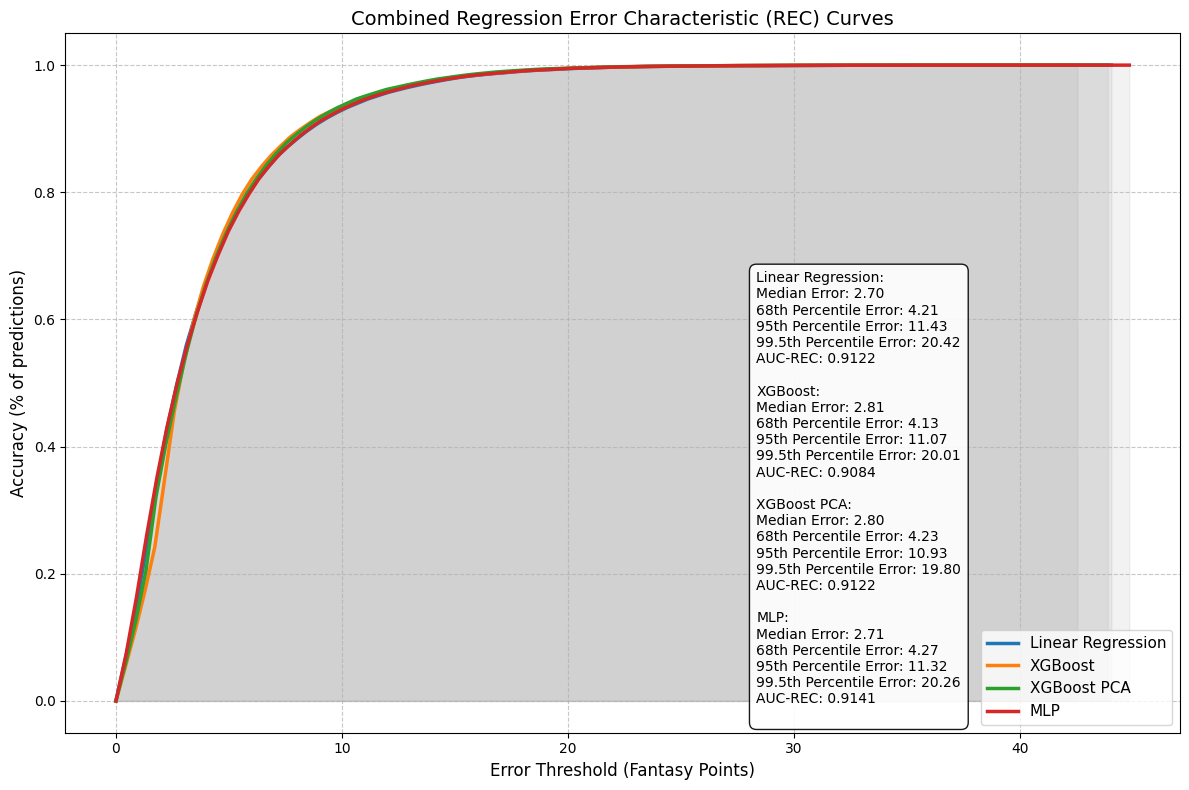

In [ ]:
# Function for COMBINED Regression Error Characteristic (REC) Curves
def plot_combined_rec_curve(model_pred_list, model_names):
    plt.figure(figsize=(12, 8))
    stats = []

    for preds, model_name in zip(model_pred_list, model_names):
        preds = preds.copy()
        
        # Calculate the absolute errors
        errors = preds['absolute_error'].values
        
        # Create threshold values from 0 to max error
        thresholds = np.linspace(0, max(errors), 100)
        
        # Calculate accuracy for each threshold
        accuracies = [np.mean(errors <= threshold) for threshold in thresholds]
        
        # Plot REC curve
        plt.plot(thresholds, accuracies, label=model_name, linewidth=2.5)
        
        # Shade the area under the curve
        plt.fill_between(thresholds, accuracies, alpha=0.1, color='grey')
        
        # Calculate statistics
        median_error = np.median(errors)
        percentile_68 = np.percentile(errors, 68)
        percentile_95 = np.percentile(errors, 95)
        percentile_99_5 = np.percentile(errors, 99.5)
        auc_rec = np.trapz(accuracies, thresholds) / (max(thresholds) * 1)  # Normalize by max threshold

        stats.append(f"{model_name}:\nMedian Error: {median_error:.2f}\n68th Percentile Error: {percentile_68:.2f}\n95th Percentile Error: {percentile_95:.2f}\n99.5th Percentile Error: {percentile_99_5:.2f}\nAUC-REC: {auc_rec:.4f}\n")

    # Add legend
    plt.legend(loc='lower right', fontsize=11)
    plt.xlabel('Error Threshold (Fantasy Points)', fontsize=12)
    plt.ylabel('Accuracy (% of predictions)', fontsize=12)
    plt.title('Combined Regression Error Characteristic (REC) Curves', fontsize=14)
    
    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add statbox
    stats_text = "\n".join(stats)
    plt.gca().text(0.62, 0.66, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))
    
    # Improve layout
    plt.tight_layout()
    plt.show()

# Call the function
plot_combined_rec_curve(model_pred_list, model_names)
